# SciBERT Model for Medical Dataset Name Extraction

This notebook trains and evaluates a **SciBERT** token classification model for extracting dataset names from medical research articles.

**Architecture:** SciBERT encoder (allenai/scibert_scivocab_uncased) -> Dropout -> Linear(768, 3) -> CrossEntropyLoss

**Prerequisites:** Run `scibert_crf_data_preparation.ipynb` first to generate tokenized data in `scibert_crf_data/`.

| Section | Description |
|---------|-------------|
| 1 | Setup and configuration |
| 2 | Load prepared SciBERT-tokenized data |
| 3 | PyTorch Dataset and DataLoader |
| 4 | SciBERT token classification model architecture |
| 5 | Training loop with initial training |
| 6 | Hyperparameter tuning with Optuna |
| 7 | Evaluation (seqeval + chunk-level exact/partial match) |
| 8 | Error analysis |
| 9 | Save model and push to HuggingFace |

## 1. Setup and Configuration

In [ ]:
# Install dependencies
%pip install -q torch transformers seqeval joblib huggingface_hub pandas matplotlib scikit-learn


In [2]:
import json
import os
import pickle
import warnings
from collections import Counter
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from seqeval.metrics import (
    classification_report as seqeval_classification_report,
    f1_score as seqeval_f1,
)
from huggingface_hub import HfApi, login
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "./scibert_crf_data"                            # Input from scibert_crf_data_preparation.ipynb
OUTPUT_DIR = "./scibert_MeDataset-NER-540-samples-OOD"                       # Output directory for model artifacts
SCIBERT_MODEL_NAME = "allenai/scibert_scivocab_uncased"    # SciBERT model
HF_REPO_ID = "haiderAI/scibert-MeDataset-NER-540-samples-OOD"             # HuggingFace repo ID
HF_PRIVATE = True                                         # Whether to make the repo private
SEED = 42

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Label mapping
label2id = {"O": 0, "B-Dataset": 1, "I-Dataset": 2}
id2label = {v: k for k, v in label2id.items()}
NUM_LABELS = len(label2id)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Device:           {DEVICE}")
print(f"SciBERT model:    {SCIBERT_MODEL_NAME}")
print(f"Data directory:   {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"HuggingFace repo: {HF_REPO_ID}")

Device:           cuda
SciBERT model:    allenai/scibert_scivocab_uncased
Data directory:   ./scibert_crf_data
Output directory: ./scibert_MeDataset-NER-540-samples-OOD
HuggingFace repo: haiderAI/scibert-MeDataset-NER-540-samples-OOD


## 2. Load Prepared Data

In [3]:
# Load SciBERT-tokenized data for all splits
def load_pickle(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

train_data = load_pickle(os.path.join(DATA_DIR, "train.pkl"))
val_data = load_pickle(os.path.join(DATA_DIR, "val.pkl"))
test_data = load_pickle(os.path.join(DATA_DIR, "test.pkl"))
ood_data = load_pickle(os.path.join(DATA_DIR, "ood.pkl"))

# Load metadata
with open(os.path.join(DATA_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)

print(f"{'Split':<8} {'Examples':>8} {'Mean Tokens':>12} {'Total Entities':>15}")
print("-" * 50)
for name, data in [("Train", train_data), ("Val", val_data),
                    ("Test", test_data), ("OOD", ood_data)]:
    lengths = [len(ex['input_ids']) for ex in data]
    n_entities = sum(len(ex['gold_entities']) for ex in data)
    print(f"{name:<8} {len(data):>8} {np.mean(lengths):>12.0f} {n_entities:>15}")

Split    Examples  Mean Tokens  Total Entities
--------------------------------------------------
Train        5133          259            9283
Val           684          265            1252
Test         1028          262            1868
OOD          2827          260            5386


In [5]:
# Display 5 sample sequences from training data
tokenizer = AutoTokenizer.from_pretrained(SCIBERT_MODEL_NAME)

print("=" * 70)
print("SAMPLE TRAINING SEQUENCES (SciBERT tokenized)")
print("=" * 70)

sample_count = 0
for ex in train_data:
    if any(l in (1, 2) for l in ex['labels']):
        print(f"--- Sample {sample_count + 1} ---")
        tokens = tokenizer.convert_ids_to_tokens(ex['input_ids'])
        print(f"Gold entities: {ex['gold_entities']}")
        print(f"Truncated: {ex['was_truncated']}")
        print(f"{'Token':<25} {'Label':>6}")
        print("-" * 35)
        for tok, label in zip(tokens, ex['labels']):
            if label == -100:
                tag_str = "  -"
            else:
                tag_str = id2label[label]
            marker = " <<" if label in (1, 2) else ""
            print(f"{tok:<25} {tag_str:>6}{marker}")
        sample_count += 1
        if sample_count >= 5:
            break

SAMPLE TRAINING SEQUENCES (SciBERT tokenized)
--- Sample 1 ---
Gold entities: ['Chimera Challenge']
Truncated: False
Token                      Label
-----------------------------------
[CLS]                          -
modal                          O
analysis                       O
is                             O
essential                      O
to                             O
guide                          O
the                            O
selective                      O
inclusion                      O
of                             O
informative                    O
modalities                     O
and                            O
prevent                        O
low                            O
-                              O
performing                     O
ones                           O
from                           O
introducing                    O
noise                          O
.                              O
this                           O
is                    

## 3. PyTorch Dataset and DataLoader

In [6]:
class NERDataset(Dataset):
    """PyTorch Dataset for SciBERT NER sequences."""

    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            'input_ids': torch.tensor(ex['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(ex['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(ex['labels'], dtype=torch.long),
        }


def collate_fn(batch, pad_token_id=0):
    """Pad batch sequences to equal length."""
    max_len = max(len(item['input_ids']) for item in batch)

    input_ids = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.full((len(batch), max_len), -100, dtype=torch.long)

    for i, item in enumerate(batch):
        seq_len = len(item['input_ids'])
        input_ids[i, :seq_len] = item['input_ids']
        attention_mask[i, :seq_len] = item['attention_mask']
        labels[i, :seq_len] = item['labels']

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
    }


# Quick sanity check
train_dataset = NERDataset(train_data)
sample = train_dataset[0]
print(f"Dataset size: {len(train_dataset)}")
print(f"Sample keys: {list(sample.keys())}")
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample labels shape: {sample['labels'].shape}")

# Test collate_fn with a small batch
test_batch = [train_dataset[i] for i in range(3)]
collated = collate_fn(test_batch, tokenizer.pad_token_id)
print(f"Collated batch shapes:")
for k, v in collated.items():
    print(f"  {k}: {v.shape}")

Dataset size: 5133
Sample keys: ['input_ids', 'attention_mask', 'labels']
Sample input_ids shape: torch.Size([73])
Sample labels shape: torch.Size([73])
Collated batch shapes:
  input_ids: torch.Size([3, 512])
  attention_mask: torch.Size([3, 512])
  labels: torch.Size([3, 512])


## 4. SciBERT Token Classification Model Architecture

In [7]:
class SciBERTTokenClassifier(nn.Module):
    """SciBERT encoder with a linear classification head for sequence labeling.

    Architecture: SciBERT -> Dropout -> Linear(768, num_labels) -> CrossEntropyLoss
    Labels of -100 are ignored by CrossEntropyLoss (special tokens, non-first subwords).
    """

    def __init__(self, model_name, num_labels=3, dropout=0.1, freeze_layers=0):
        super().__init__()
        self.scibert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(self.scibert.config.hidden_size, num_labels)
        self.num_labels = num_labels
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

        # Optionally freeze lower SciBERT layers to reduce overfitting
        if freeze_layers > 0:
            for param in self.scibert.embeddings.parameters():
                param.requires_grad = False
            for i in range(min(freeze_layers, len(self.scibert.encoder.layer))):
                for param in self.scibert.encoder.layer[i].parameters():
                    param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.scibert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = self.dropout(outputs.last_hidden_state)
        logits = self.linear(sequence_output)  # (batch, seq_len, num_labels)

        if labels is not None:
            # Training: cross-entropy loss (ignores -100 positions)
            loss = self.loss_fn(logits.view(-1, self.num_labels), labels.view(-1))
            return loss
        else:
            # Inference: argmax predictions
            predictions = torch.argmax(logits, dim=-1)  # (batch, seq_len)
            return predictions

In [8]:
# Model parameter summary
model = SciBERTTokenClassifier(SCIBERT_MODEL_NAME, num_labels=NUM_LABELS)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"SciBERT hidden size:  {model.scibert.config.hidden_size}")
print(f"SciBERT layers:       {len(model.scibert.encoder.layer)}")
print(f"Linear layer:         {model.linear.in_features} -> {model.linear.out_features}")

# Component breakdown
scibert_params = sum(p.numel() for p in model.scibert.parameters())
linear_params = sum(p.numel() for p in model.linear.parameters())
print(f"Parameter breakdown:")
print(f"  SciBERT encoder: {scibert_params:>12,} ({scibert_params/total_params:.1%})")
print(f"  Linear layer:    {linear_params:>12,} ({linear_params/total_params:.1%})")

del model  # free memory before training

Total parameters:     109,920,771
Trainable parameters: 109,920,771
SciBERT hidden size:  768
SciBERT layers:       12
Linear layer:         768 -> 3
Parameter breakdown:
  SciBERT encoder:  109,918,464 (100.0%)
  Linear layer:           2,307 (0.0%)


## 5. Training Loop and Initial Training

In [9]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device, max_grad_norm=1.0):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels'],
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(dataloader)


def evaluate_seqeval(model, dataloader, device, id2label_map):
    """Run inference and return seqeval-compatible tag sequences + raw pred IDs."""
    model.eval()
    all_preds = []
    all_labels = []
    all_pred_ids = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            predictions = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
            )  # (batch, seq_len)

            labels_batch = batch['labels']

            for i in range(labels_batch.size(0)):
                # Only evaluate at positions where labels != -100
                # (first-subword content tokens, same as old crf_mask=True)
                valid_mask = labels_batch[i] != -100
                true_labels_i = labels_batch[i][valid_mask].cpu().tolist()
                pred_labels_i = predictions[i][valid_mask].cpu().tolist()

                true_tags = [id2label_map[l] for l in true_labels_i]
                pred_tags = [id2label_map[l] for l in pred_labels_i]

                all_preds.append(pred_tags)
                all_labels.append(true_tags)
                all_pred_ids.append(pred_labels_i)

    return all_preds, all_labels, all_pred_ids


def run_training(model, train_loader, val_loader, optimizer, scheduler,
                 device, num_epochs, patience, max_grad_norm=1.0, save_path=None):
    """Full training loop with early stopping. Returns training history."""
    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_f1': []}

    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, max_grad_norm)
        val_preds, val_labels, _ = evaluate_seqeval(model, val_loader, device, id2label)
        val_f1 = seqeval_f1(val_labels, val_preds)

        history['train_loss'].append(train_loss)
        history['val_f1'].append(val_f1)

        epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", val_f1=f"{val_f1:.4f}")
        print(f"Epoch {epoch+1}/{num_epochs}: loss={train_loss:.4f}, val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            if save_path:
                torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Best validation F1: {best_val_f1:.4f}")
    return history, best_val_f1

In [10]:
# Default hyperparameters for initial training
ENCODER_LR = 2e-5
HEAD_LR = 1e-3
DROPOUT = 0.1
BATCH_SIZE = 16
NUM_EPOCHS = 15
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
FREEZE_LAYERS = 0
PATIENCE = 3

# Create model
model = SciBERTTokenClassifier(SCIBERT_MODEL_NAME, NUM_LABELS, DROPOUT, FREEZE_LAYERS).to(DEVICE)

# DataLoaders
train_loader = DataLoader(
    NERDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)
val_loader = DataLoader(
    NERDataset(val_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)

# Optimizer with differential learning rates
scibert_params = list(model.scibert.parameters())
head_params = list(model.linear.parameters())
optimizer = torch.optim.AdamW([
    {'params': scibert_params, 'lr': ENCODER_LR, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params, 'lr': HEAD_LR, 'weight_decay': 0.0},
])

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

save_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
print(f"Training with default hyperparameters...")
print(f"  Encoder LR: {ENCODER_LR}, Head LR: {HEAD_LR}")
print(f"  Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")
print(f"  Warmup steps: {warmup_steps}/{total_steps}")
print()

history, best_f1 = run_training(
    model, train_loader, val_loader, optimizer, scheduler,
    DEVICE, NUM_EPOCHS, PATIENCE, MAX_GRAD_NORM, save_path)

Training with default hyperparameters...
  Encoder LR: 2e-05, Head LR: 0.001
  Batch size: 16, Epochs: 15
  Warmup steps: 481/4815



Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/321 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 1/15: loss=0.1602, val_f1=0.6332


...

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 11/15: loss=0.0006, val_f1=0.8961


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 12/15: loss=0.0004, val_f1=0.8947
Early stopping at epoch 12
Best validation F1: 0.8972


Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation set - seqeval classification report:
              precision    recall  f1-score   support

     Dataset       0.87      0.93      0.90      1246

   micro avg       0.87      0.93      0.90      1246
   macro avg       0.87      0.93      0.90      1246
weighted avg       0.87      0.93      0.90      1246



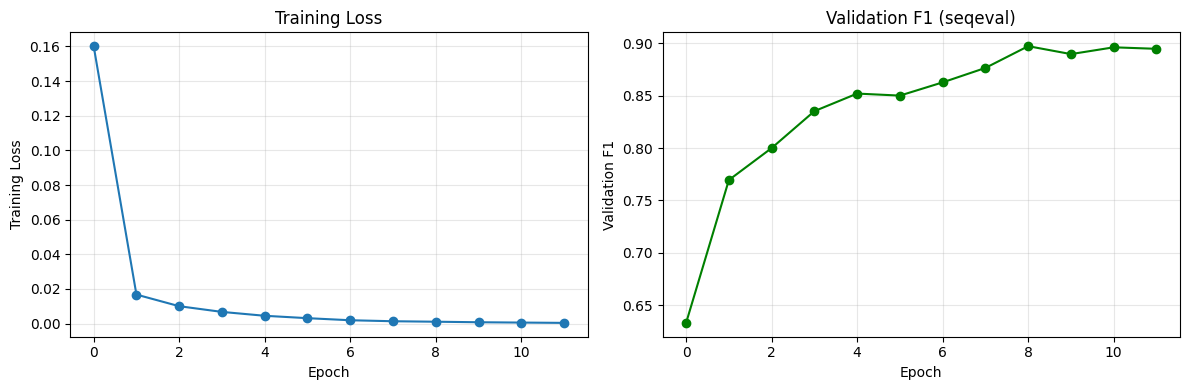


Training complete. Best val F1: 0.8972


In [11]:
# Load best model and print detailed validation report
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pt'), map_location=DEVICE))
val_preds, val_labels, _ = evaluate_seqeval(model, val_loader, DEVICE, id2label)

print("Validation set - seqeval classification report:")
print(seqeval_classification_report(val_labels, val_preds))

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_f1'], marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation F1')
ax2.set_title('Validation F1 (seqeval)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'initial_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining complete. Best val F1: {best_f1:.4f}")

## 6. Evaluation on Test and OOD Sets

In [12]:
# seqeval classification report on test set
test_loader = DataLoader(
    NERDataset(test_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id))

test_preds, test_labels, test_pred_ids = evaluate_seqeval(model, test_loader, DEVICE, id2label)
test_f1_seqeval = seqeval_f1(test_labels, test_preds)

print("=" * 60)
print("TEST SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(test_labels, test_preds))
print(f"Entity-level F1 (seqeval): {test_f1_seqeval:.4f}")

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

TEST SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.84      0.94      0.89      1856

   micro avg       0.84      0.94      0.89      1856
   macro avg       0.84      0.94      0.89      1856
weighted avg       0.84      0.94      0.89      1856

Entity-level F1 (seqeval): 0.8869


In [13]:
def scibert_bio_to_entity_strings(example, pred_tags, tokenizer_obj, id2label_map):
    """Decode predictions back to entity strings using word grouping.

    Args:
        example: dict from data prep (has input_ids, word_ids, offset_mapping, text)
        pred_tags: list of predicted label ids for first-subword positions (labels != -100)
        tokenizer_obj: SciBERT tokenizer (unused but kept for API consistency)
        id2label_map: {0: 'O', 1: 'B-Dataset', 2: 'I-Dataset'}

    Returns:
        List of predicted entity strings
    """
    input_ids = example['input_ids']
    word_ids_raw = example['word_ids']
    offset_mapping = example['offset_mapping']
    text = example['text']

    # Identify first-subword positions (same positions as labels != -100)
    seen_words = set()
    first_subword_positions = []
    for pos in range(len(input_ids)):
        wid = word_ids_raw[pos]
        if wid is not None and wid not in seen_words:
            seen_words.add(wid)
            first_subword_positions.append(pos)

    # Map predictions to word-level tags
    word_tags = {}  # word_id -> tag string
    for tag_idx, pos in enumerate(first_subword_positions):
        if tag_idx < len(pred_tags):
            wid = word_ids_raw[pos]
            word_tags[wid] = id2label_map[pred_tags[tag_idx]]

    # Get word character spans from offset_mapping
    word_spans = {}  # word_id -> (char_start, char_end)
    for pos in range(len(input_ids)):
        wid = word_ids_raw[pos]
        if wid is not None:
            tok_start, tok_end = offset_mapping[pos]
            if tok_end == 0:
                continue
            if wid not in word_spans:
                word_spans[wid] = (tok_start, tok_end)
            else:
                word_spans[wid] = (word_spans[wid][0], max(word_spans[wid][1], tok_end))

    # Decode entities using BIO tags on words
    entities = []
    current_start = None
    current_end = None

    for wid in sorted(word_spans.keys()):
        tag = word_tags.get(wid, 'O')
        ws, we = word_spans[wid]

        if tag.startswith('B-'):
            if current_start is not None:
                entities.append(text[current_start:current_end])
            current_start = ws
            current_end = we
        elif tag.startswith('I-') and current_start is not None:
            current_end = we
        else:
            if current_start is not None:
                entities.append(text[current_start:current_end])
                current_start = None
                current_end = None

    if current_start is not None:
        entities.append(text[current_start:current_end])

    return entities


def evaluate_chunk_level(data_examples, all_pred_tag_ids, tokenizer_obj, id2label_map):
    """Chunk-level exact & partial match evaluation."""
    tp = fp = fn = 0
    partial_tp = 0

    for ex, pred_tags in zip(data_examples, all_pred_tag_ids):
        pred_entities = scibert_bio_to_entity_strings(ex, pred_tags, tokenizer_obj, id2label_map)
        gold_entities = ex['gold_entities']

        true_set = set(e.strip().lower() for e in gold_entities)
        pred_set = set(e.strip().lower() for e in pred_entities)

        # Exact match
        tp += len(true_set & pred_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        # Partial match
        for pmention in pred_set:
            if pmention not in true_set:
                for tmention in true_set:
                    if pmention in tmention or tmention in pmention:
                        partial_tp += 1
                        break

    # Compute metrics
    exact_p = tp / (tp + fp) if (tp + fp) > 0 else 0
    exact_r = tp / (tp + fn) if (tp + fn) > 0 else 0
    exact_f1 = 2 * exact_p * exact_r / (exact_p + exact_r) if (exact_p + exact_r) > 0 else 0

    adj_tp = tp + partial_tp
    partial_p = adj_tp / (adj_tp + fp - partial_tp) if (adj_tp + fp - partial_tp) > 0 else 0
    partial_r = adj_tp / (adj_tp + fn - partial_tp) if (adj_tp + fn - partial_tp) > 0 else 0
    partial_f1 = 2 * partial_p * partial_r / (partial_p + partial_r) if (partial_p + partial_r) > 0 else 0

    return {
        "exact_match": {"precision": exact_p, "recall": exact_r, "f1": exact_f1,
                        "tp": tp, "fp": fp, "fn": fn},
        "partial_match": {"precision": partial_p, "recall": partial_r, "f1": partial_f1,
                          "partial_tp": partial_tp},
    }

In [14]:
# Chunk-level evaluation on test and validation sets
test_metrics = evaluate_chunk_level(test_data, test_pred_ids, tokenizer, id2label)

# Also get val predictions for comparison
val_preds_final, val_labels_final, val_pred_ids = evaluate_seqeval(model, val_loader, DEVICE, id2label)
val_metrics = evaluate_chunk_level(val_data, val_pred_ids, tokenizer, id2label)

print("=" * 60)
print("CHUNK-LEVEL EVALUATION (matching CRF baseline methodology)")
print("=" * 60)

print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10}")
print("-" * 45)
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f}")
print(f"\n{'Counts':<20} {'Val':>10} {'Test (ID)':>10}")
print("-" * 45)
print(f"{'TP':<20} {val_metrics['exact_match']['tp']:>10} {test_metrics['exact_match']['tp']:>10}")
print(f"{'FP':<20} {val_metrics['exact_match']['fp']:>10} {test_metrics['exact_match']['fp']:>10}")
print(f"{'FN':<20} {val_metrics['exact_match']['fn']:>10} {test_metrics['exact_match']['fn']:>10}")
print(f"{'Partial TP':<20} {val_metrics['partial_match']['partial_tp']:>10} {test_metrics['partial_match']['partial_tp']:>10}")

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

CHUNK-LEVEL EVALUATION (matching CRF baseline methodology)

Metric                      Val  Test (ID)
---------------------------------------------
Exact P                  0.8795     0.8559
Exact R                  0.9257     0.9424
Exact F1                 0.9020     0.8971
Partial P                0.9313     0.9046
Partial R                0.9802     0.9959
Partial F1               0.9551     0.9480

Counts                      Val  Test (ID)
---------------------------------------------
TP                          934       1390
FP                          128        234
FN                           75         85
Partial TP                   55         79


### Out-of-Distribution (OOD) Evaluation

The OOD set tests generalization to entirely new documents not seen during training.
Same processing pipeline (negative sampling + augmentation) applied for consistency with val/test splits.

In [15]:
# seqeval classification report on OOD set
ood_loader = DataLoader(
    NERDataset(ood_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)

ood_preds, ood_labels, ood_pred_ids = evaluate_seqeval(model, ood_loader, DEVICE, id2label)
ood_f1_seqeval = seqeval_f1(ood_labels, ood_preds)

print("=" * 60)
print("OOD SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(ood_labels, ood_preds))
print(f"Entity-level F1 (seqeval): {ood_f1_seqeval:.4f}")

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

OOD SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.67      0.68      0.67      5384

   micro avg       0.67      0.68      0.67      5384
   macro avg       0.67      0.68      0.67      5384
weighted avg       0.67      0.68      0.67      5384

Entity-level F1 (seqeval): 0.6741


In [16]:
# Chunk-level evaluation on OOD set + side-by-side comparison
ood_metrics = evaluate_chunk_level(ood_data, ood_pred_ids, tokenizer, id2label)

print("=" * 60)
print("COMPARISON: Val vs Test (ID) vs OOD")
print("=" * 60)

print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10} {'OOD':>10}")
print("-" * 55)
print(f"{'seqeval F1':<20} {seqeval_f1(val_labels_final, val_preds_final):>10.4f} {test_f1_seqeval:>10.4f} {ood_f1_seqeval:>10.4f}")
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f} {ood_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f} {ood_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f} {ood_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f} {ood_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f} {ood_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f} {ood_metrics['partial_match']['f1']:>10.4f}")

# Compare with CRF baseline if available
crf_metrics_path = "./crf_medical_ner/eval_metrics.json"
if os.path.exists(crf_metrics_path):
    with open(crf_metrics_path, 'r') as f:
        crf_eval = json.load(f)
    print("\n" + "=" * 60)
    print("CRF BASELINE vs SciBERT COMPARISON (Test Set)")
    print("=" * 60)
    if 'test' in crf_eval:
        crf_test = crf_eval['test']
        print(f"\n{'Metric':<20} {'CRF':>10} {'SciBERT':>12} {'Delta':>10}")
        print("-" * 55)
        if 'seqeval_f1' in crf_test:
            delta = test_f1_seqeval - crf_test['seqeval_f1']
            print(f"{'seqeval F1':<20} {crf_test['seqeval_f1']:>10.4f} {test_f1_seqeval:>12.4f} {delta:>+10.4f}")
        if 'exact_match' in crf_test:
            delta = test_metrics['exact_match']['f1'] - crf_test['exact_match']['f1']
            print(f"{'Exact F1':<20} {crf_test['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>12.4f} {delta:>+10.4f}")
        if 'partial_match' in crf_test:
            delta = test_metrics['partial_match']['f1'] - crf_test['partial_match']['f1']
            print(f"{'Partial F1':<20} {crf_test['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>12.4f} {delta:>+10.4f}")
else:
    print("\nNote: CRF baseline metrics not found at", crf_metrics_path)

COMPARISON: Val vs Test (ID) vs OOD

Metric                      Val  Test (ID)        OOD
-------------------------------------------------------
seqeval F1               0.8972     0.8869     0.6741
Exact P                  0.8795     0.8559     0.7096
Exact R                  0.9257     0.9424     0.7111
Exact F1                 0.9020     0.8971     0.7104
Partial P                0.9313     0.9046     0.8468
Partial R                0.9802     0.9959     0.8486
Partial F1               0.9551     0.9480     0.8477

Note: CRF baseline metrics not found at ./crf_medical_ner/eval_metrics.json


## 7. Error Analysis

In [17]:
# Collect concrete examples of TP, FP, FN, and partial matches
def collect_error_examples(data_examples, all_pred_tag_ids, tokenizer_obj, id2label_map):
    """Collect per-chunk TP, FP, FN, and partial match examples."""
    tp_examples = []
    fp_examples = []
    fn_examples = []
    partial_examples = []

    for ex, pred_tags in zip(data_examples, all_pred_tag_ids):
        pred_entities = scibert_bio_to_entity_strings(ex, pred_tags, tokenizer_obj, id2label_map)
        gold_entities = ex['gold_entities']

        true_set = set(e.strip().lower() for e in gold_entities)
        pred_set = set(e.strip().lower() for e in pred_entities)

        for e in true_set & pred_set:
            tp_examples.append(e)
        for e in pred_set - true_set:
            fp_examples.append(e)
        for e in true_set - pred_set:
            fn_examples.append(e)
        for pmention in pred_set:
            if pmention not in true_set:
                for tmention in true_set:
                    if pmention in tmention or tmention in pmention:
                        partial_examples.append((pmention, tmention))
                        break

    return tp_examples, fp_examples, fn_examples, partial_examples

tp_examples, fp_examples, fn_examples, partial_examples = collect_error_examples(
    test_data, test_pred_ids, tokenizer, id2label
)

print("=" * 60)
print("TEST SET ERROR EXAMPLES")
print("=" * 60)

print(f"\nTP: {len(tp_examples)}, FP: {len(fp_examples)}, FN: {len(fn_examples)}, Partial: {len(partial_examples)}")

print(f"\n--- True Positives (showing 5 of {len(tp_examples)}) ---")
for e in tp_examples[:5]:
    print(f"  {e}")

print(f"\n--- False Positives (showing 5 of {len(fp_examples)}) ---")
for e in fp_examples[:5]:
    print(f"  {e}")

print(f"\n--- False Negatives (showing 5 of {len(fn_examples)}) ---")
for e in fn_examples[:5]:
    print(f"  {e}")

print(f"\n--- Partial Matches (showing 5 of {len(partial_examples)}) ---")
for pred, gold in partial_examples[:5]:
    print(f"  Predicted: '{pred}' | Gold: '{gold}'")

TEST SET ERROR EXAMPLES

TP: 1390, FP: 234, FN: 85, Partial: 79

--- True Positives (showing 5 of 1390) ---
  brats2019 brain tumour dataset
  brats 2018 dataset
  mendeley v2 dataset
  rsna str pulmonary embolism detection
  brats 2015 datasets

--- False Positives (showing 5 of 234) ---
  cifar10
  things-meg dataset
  things-eeg
  medseg
  covid

--- False Negatives (showing 5 of 85) ---
  covid-19 dataset from medseg
  chestct.
  sdd
  tgen
  lits

--- Partial Matches (showing 5 of 79) ---
  Predicted: 'medseg' | Gold: 'covid-19 dataset from medseg'
  Predicted: 'covid' | Gold: 'covid-19 dataset from medseg'
  Predicted: 'sdd sets' | Gold: 'sdd'
  Predicted: 'visceral' | Gold: 'visceral dataset'
  Predicted: 'brats 2019 dataset' | Gold: 'miccai brats 2019 dataset'


In [18]:
# Error pattern analysis
print("=" * 60)
print("ERROR PATTERNS")
print("=" * 60)

# FP/FN by entity word count
fp_word_counts = Counter(len(e.split()) for e in fp_examples)
fn_word_counts = Counter(len(e.split()) for e in fn_examples)
tp_word_counts = Counter(len(e.split()) for e in tp_examples)

print("\nEntity length distribution (word count):")
all_lengths = sorted(set(list(fp_word_counts.keys()) + list(fn_word_counts.keys()) + list(tp_word_counts.keys())))
print(f"{'Length':<10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 35)
for length in all_lengths[:10]:
    print(f"{length:<10} {tp_word_counts.get(length, 0):>6} {fp_word_counts.get(length, 0):>6} {fn_word_counts.get(length, 0):>6}")

# Top 10 most common FP and FN
print(f"\n--- Top 10 Most Common False Positives ---")
for e, count in Counter(fp_examples).most_common(10):
    print(f"  [{count}x] {e}")

print(f"\n--- Top 10 Most Common False Negatives ---")
for e, count in Counter(fn_examples).most_common(10):
    print(f"  [{count}x] {e}")

ERROR PATTERNS

Entity length distribution (word count):
Length         TP     FP     FN
-----------------------------------
1             572    113     34
2             501     65     26
3             147     31     12
4              77      7      5
5              55      4      6
6              16      3      1
7              10      5      0
8               7      5      1
9               3      1      0
11              2      0      0

--- Top 10 Most Common False Positives ---
  [4x] brats
  [3x] brats dataset
  [2x] cambridge
  [2x] kaggle chest dataset
  [2x] chexpert
  [2x] nih
  [2x] pfam
  [2x] iu x-ray
  [2x] cov-ctr dataset
  [2x] phenom

--- Top 10 Most Common False Negatives ---
  [3x] x-ray datasets
  [2x] brats 2018
  [2x] ghs-pop data
  [2x] lidc
  [2x] biocreative
  [2x] zhou2016
  [2x] spie-aapm-nci lung nodule classification challenge
  [2x] umls
  [2x] endovissub
  [2x] brats


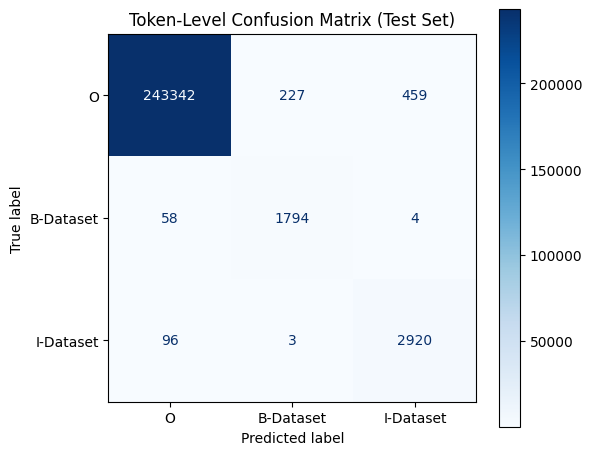

Per-class accuracy:
  O: 243342/244028 (99.7%)
  B-Dataset: 1794/1856 (96.7%)
  I-Dataset: 2920/3019 (96.7%)


In [20]:
# Token-level confusion matrix visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten all test predictions and true labels
all_true_flat = [l for seq in test_labels for l in seq]
all_pred_flat = [p for seq in test_preds for p in seq]

labels_list = ['O', 'B-Dataset', 'I-Dataset']
cm = confusion_matrix(all_true_flat, all_pred_flat, labels=labels_list)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_list)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Token-Level Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("Per-class accuracy:")
for i, label in enumerate(labels_list):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"  {label}: {correct}/{total} ({acc:.1%})")

In [21]:
# OOD-specific error analysis
print("=" * 60)
print("OOD ERROR ANALYSIS")
print("=" * 60)

ood_tp, ood_fp, ood_fn, ood_partial = collect_error_examples(
    ood_data, ood_pred_ids, tokenizer, id2label
)

print(f"\nOOD TP: {len(ood_tp)}, FP: {len(ood_fp)}, FN: {len(ood_fn)}, Partial: {len(ood_partial)}")

print(f"\n--- OOD False Positives (showing 5 of {len(ood_fp)}) ---")
for e in ood_fp[:5]:
    print(f"  {e}")

print(f"\n--- OOD False Negatives (showing 5 of {len(ood_fn)}) ---")
for e in ood_fn[:5]:
    print(f"  {e}")

print(f"\n--- OOD Partial Matches (showing 5 of {len(ood_partial)}) ---")
for pred, gold in ood_partial[:5]:
    print(f"  Predicted: '{pred}' | Gold: '{gold}'")

# Compare error rates: ID vs OOD
id_error_rate = (len(fp_examples) + len(fn_examples)) / max(len(tp_examples) + len(fp_examples) + len(fn_examples), 1)
ood_error_rate = (len(ood_fp) + len(ood_fn)) / max(len(ood_tp) + len(ood_fp) + len(ood_fn), 1)
print(f"\nError rate comparison:")
print(f"  Test (ID): {id_error_rate:.3f}")
print(f"  OOD:       {ood_error_rate:.3f}")

# Top OOD FN
print(f"\n--- Top 10 Most Common OOD False Negatives ---")
for e, count in Counter(ood_fn).most_common(10):
    print(f"  [{count}x] {e}")

OOD ERROR ANALYSIS

OOD TP: 3006, FP: 1230, FN: 1221, Partial: 581

--- OOD False Positives (showing 5 of 1230) ---
  gigascience database
  camelyon16
  chest x-ray images
  breast ultrasound images dataset
  brats2017,

--- OOD False Negatives (showing 5 of 1221) ---
  uci machine learning repository
  covid-19 ct
  busi
  tcga-ucec cohorts
  university of waterloo skin cancer dataset

--- OOD Partial Matches (showing 5 of 581) ---
  Predicted: 'camelyon16' | Gold: 'camelyon16 dataset'
  Predicted: 'brats2017,' | Gold: 'brats2017'
  Predicted: 'brats2018,' | Gold: 'brats2018'
  Predicted: 'university of' | Gold: 'university of waterloo skin cancer dataset'
  Predicted: 'covid-' | Gold: 'covid-19-ar dataset'

Error rate comparison:
  Test (ID): 0.187
  OOD:       0.449

--- Top 10 Most Common OOD False Negatives ---
  [34x] shidc-b-ki-67
  [27x] busi
  [23x] iq-oth/nccd dataset
  [21x] panda
  [19x] uk biobank
  [19x] mood
  [18x] skin-psoct
  [15x] cbis-ddsm
  [15x] bach
  [15x] da_d

## 8. Save Model and Push to HuggingFace

In [22]:
# best_model.pt was already saved during training (Section 5)
print(f"Model checkpoint: {os.path.join(OUTPUT_DIR, 'best_model.pt')}")
print(f"  Size: {os.path.getsize(os.path.join(OUTPUT_DIR, 'best_model.pt'))/1024/1024:.1f} MB")

# Save config.json
config = {
    "model_type": "scibert-token-classification",
    "scibert_model": SCIBERT_MODEL_NAME,
    "num_labels": NUM_LABELS,
    "entity_types": ["Dataset"],
    "entity_description": "Names of datasets, corpus, collections, databases, benchmarks used in scientific research",
    "bio_labels": ["O", "B-Dataset", "I-Dataset"],
    "label2id": label2id,
    "hyperparameters": {
        "encoder_lr": ENCODER_LR,
        "head_lr": HEAD_LR,
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "freeze_layers": FREEZE_LAYERS,
    },
    "training_data": {
        "source": metadata.get("source_file", "data-annotations.json"),
        "total_documents": metadata.get("total_documents", "unknown"),
        "train_examples": len(train_data),
        "val_examples": len(val_data),
        "test_examples": len(test_data),
        "ood_examples": len(ood_data),
        "chunk_size": metadata.get("chunk_size", 1500),
        "chunk_overlap": metadata.get("chunk_overlap", 300),
        "max_seq_length": metadata.get("max_seq_length", 512),
    },
}

with open(os.path.join(OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f"Saved config.json")

# Save eval_metrics.json
val_f1_final = seqeval_f1(val_labels_final, val_preds_final)
eval_metrics = {
    "val": {
        "seqeval_f1": val_f1_final,
        "exact_match": val_metrics["exact_match"],
        "partial_match": val_metrics["partial_match"],
    },
    "test": {
        "seqeval_f1": test_f1_seqeval,
        "exact_match": test_metrics["exact_match"],
        "partial_match": test_metrics["partial_match"],
    },
    "ood": {
        "seqeval_f1": ood_f1_seqeval,
        "exact_match": ood_metrics["exact_match"],
        "partial_match": ood_metrics["partial_match"],
    },
}

with open(os.path.join(OUTPUT_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=2)
print(f"Saved eval_metrics.json")

Model checkpoint: ./scibert_MeDataset-NER-540-samples-OOD/best_model.pt
  Size: 419.4 MB
Saved config.json
Saved eval_metrics.json


In [31]:
%%writefile ./scibert_MeDataset-NER-540-samples-OOD/inference.py
"""Standalone inference script for SciBERT Medical Dataset NER model."""
import json
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer


class SciBERTTokenClassifier(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.1, freeze_layers=0):
        super().__init__()
        self.scibert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(
            self.scibert.config.hidden_size, num_labels
        )
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.scibert(
            input_ids=input_ids, attention_mask=attention_mask
        )
        seq_out = self.dropout(outputs.last_hidden_state)
        logits = self.linear(seq_out)
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fn(logits.view(-1, self.num_labels), labels.view(-1))
            return loss
        return torch.argmax(logits, dim=-1)


def load_model(model_dir, device="cpu"):
    with open(f"{model_dir}/config.json", "r") as f:
        config = json.load(f)

    model = SciBERTTokenClassifier(
        config["scibert_model"],
        config["num_labels"],
        config["hyperparameters"].get("dropout", 0.1),
        config["hyperparameters"].get("freeze_layers", 0),
    )
    model.load_state_dict(
        torch.load(f"{model_dir}/best_model.pt", map_location=device)
    )
    model.to(device).eval()

    tokenizer = AutoTokenizer.from_pretrained(config["scibert_model"])
    id2label = {int(v): k for k, v in config["label2id"].items()}
    return model, tokenizer, id2label, config


def predict(text, model, tokenizer, id2label, device="cpu", max_length=512):
    enc = tokenizer(
        text, return_offsets_mapping=True, add_special_tokens=True,
        truncation=True, max_length=max_length,
        return_attention_mask=True, return_tensors="pt"
    )
    ids = enc["input_ids"].to(device)
    attn = enc["attention_mask"].to(device)
    offsets = enc["offset_mapping"][0].tolist()
    wids = enc.word_ids(0)

    with torch.no_grad():
        preds = model(input_ids=ids, attention_mask=attn)[0].cpu().tolist()

    word_tags = {}
    seen = set()
    for i, wid in enumerate(wids):
        if wid is not None and wid not in seen:
            seen.add(wid)
            word_tags[wid] = id2label[preds[i]]

    word_spans = {}
    for i, wid in enumerate(wids):
        if wid is not None:
            s, e = offsets[i]
            if e == 0: continue
            word_spans[wid] = (s, max(word_spans.get(wid, (s, 0))[1], e))

    entities, curr_s, curr_e = [], None, None
    for wid in sorted(word_spans.keys()):
        tag = word_tags.get(wid, "O")
        s, e = word_spans[wid]
        if tag.startswith("B-"):
            if curr_s is not None:
                entities.append({"text": text[curr_s:curr_e],
                                 "start": curr_s, "end": curr_e,
                                 "label": "Dataset"})
            curr_s, curr_e = s, e
        elif tag.startswith("I-") and curr_s is not None:
            curr_e = e
        else:
            if curr_s is not None:
                entities.append({"text": text[curr_s:curr_e],
                                 "start": curr_s, "end": curr_e,
                                 "label": "Dataset"})
                curr_s, curr_e = None, None
    if curr_s is not None:
        entities.append({"text": text[curr_s:curr_e],
                         "start": curr_s, "end": curr_e,
                         "label": "Dataset"})
    return entities


if __name__ == "__main__":
    import sys
    d = sys.argv[1] if len(sys.argv) > 1 else "."
    model, tok, id2l, cfg = load_model(d)
    print("Loaded SciBERT model from {}".format(d))
    print("  Model: {}".format(cfg["scibert_model"]))
    print("  Labels: {}".format(
        cfg.get("bio_labels", list(id2l.values()))
    ))

    txt = "We evaluated our method on the MIMIC-III dataset."
    print("\nSample text: {}".format(txt))
    ents = predict(txt, model, tok, id2l)
    print("Entities found: {}".format(len(ents)))
    for ent in ents:
        print("  [{}:{}] {} ({})".format(
            ent["start"], ent["end"], ent["text"], ent["label"]
        ))

Overwriting ./scibert_MeDataset-NER-540-samples-OOD/inference.py


In [32]:
# HuggingFace login
login()  # Will prompt for token or use cached credentials
api = HfApi()

In [33]:
# Generate model card README.md
em = test_metrics['exact_match']
pm = test_metrics['partial_match']
vem = val_metrics['exact_match']
vpm = val_metrics['partial_match']
oem = ood_metrics['exact_match']
opm = ood_metrics['partial_match']

model_card = f"""---
tags:
  - scibert
  - ner
  - medical
  - pytorch
  - dataset-extraction
  - token-classification
license: apache-2.0
---

# SciBERT - Medical Dataset Name Extraction

A **SciBERT** token classification model trained to extract dataset names from medical/scientific research papers. Uses SciBERT (allenai/scibert_scivocab_uncased) as the encoder with a linear classification head and cross-entropy loss.

## Architecture



- **Encoder:** SciBERT (allenai/scibert_scivocab_uncased) for domain-specific contextual embeddings
- **Classification Head:** Linear layer with softmax for BIO label prediction
- **Differential Learning Rates:** Lower LR for SciBERT encoder, higher for classification head

## Entity Types

| Entity Type | Description |
|---|---|
|  | Names of datasets, corpus, collections, databases, benchmarks used in scientific research |

## Performance

### Validation Set
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {seqeval_f1(val_labels_final, val_preds_final):.4f} |
| Exact Match (chunk) | {vem['precision']:.4f} | {vem['recall']:.4f} | {vem['f1']:.4f} |
| Partial Match (chunk) | {vpm['precision']:.4f} | {vpm['recall']:.4f} | {vpm['f1']:.4f} |

### Test Set (In-Distribution)
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {test_f1_seqeval:.4f} |
| Exact Match (chunk) | {em['precision']:.4f} | {em['recall']:.4f} | {em['f1']:.4f} |
| Partial Match (chunk) | {pm['precision']:.4f} | {pm['recall']:.4f} | {pm['f1']:.4f} |

### OOD Set (Out-of-Distribution)
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {ood_f1_seqeval:.4f} |
| Exact Match (chunk) | {oem['precision']:.4f} | {oem['recall']:.4f} | {oem['f1']:.4f} |
| Partial Match (chunk) | {opm['precision']:.4f} | {opm['recall']:.4f} | {opm['f1']:.4f} |

## Training Details

| Parameter | Value |
|---|---|
| Base model | allenai/scibert_scivocab_uncased |
| Max sequence length | 512 |
| Training documents | {metadata.get('total_documents', 'N/A')} |
| Training examples | {len(train_data)} |

## Usage



## Dependencies



## Limitations

- Only recognizes dataset/corpus/database names, not other biomedical entities
- Max input length of 512 SciBERT tokens (~1500 characters)
- Trained on manually annotated medical research abstracts; may not generalize well to other scientific domains
"""

with open(os.path.join(OUTPUT_DIR, 'README.md'), 'w') as f:
    f.write(model_card)
print("Saved README.md (model card)")

Saved README.md (model card)


In [34]:
# Upload to HuggingFace Hub
print(f"Target repo: {HF_REPO_ID}")

api.create_repo(
    repo_id=HF_REPO_ID,
    private=HF_PRIVATE,
    exist_ok=True,
)

# Upload all artifacts
files_to_upload = [
    ('best_model.pt', 'best_model.pt'),
    ('config.json', 'config.json'),
    ('eval_metrics.json', 'eval_metrics.json'),
    ('inference.py', 'inference.py'),
    ('README.md', 'README.md'),
]

for local_name, repo_name in files_to_upload:
    local_path = os.path.join(OUTPUT_DIR, local_name)
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_name,
        repo_id=HF_REPO_ID,
        commit_message=f"Upload {repo_name}",
    )
    print(f"  Uploaded: {repo_name}")

print(f"\nAll artifacts uploaded to: https://huggingface.co/{HF_REPO_ID}")

Target repo: haiderAI/scibert-MeDataset-NER-540-samples-OOD


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded: best_model.pt
  Uploaded: config.json
  Uploaded: eval_metrics.json
  Uploaded: inference.py
  Uploaded: README.md

All artifacts uploaded to: https://huggingface.co/haiderAI/scibert-MeDataset-NER-540-samples-OOD


In [35]:
# Final summary
print("=" * 60)
print("SciBERT MODEL TRAINING COMPLETE")
print("=" * 60)

print(f"\nModel artifacts saved to: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        unit = 'KB' if size < 1024 * 1024 else 'MB'
        size_val = size / 1024 if unit == 'KB' else size / 1024 / 1024
        print(f"  {fname:<30} {size_val:>8.1f} {unit}")

print(f"\nHuggingFace repo: https://huggingface.co/{HF_REPO_ID}")

print(f"\nHyperparameters:")
hp_dict = {
    "encoder_lr": ENCODER_LR,
    "head_lr": HEAD_LR,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "freeze_layers": FREEZE_LAYERS,
}
for k, v in hp_dict.items():
    print(f"  {k}: {v}")

print(f"\nKey metrics:")
print(f"  {'':20} {'Val':>10} {'Test':>10} {'OOD':>10}")
print(f"  {'-'*55}")
print(f"  {'seqeval F1':20} {seqeval_f1(val_labels_final, val_preds_final):>10.4f} {test_f1_seqeval:>10.4f} {ood_f1_seqeval:>10.4f}")
print(f"  {'Exact F1':20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f} {ood_metrics['exact_match']['f1']:>10.4f}")
print(f"  {'Partial F1':20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f} {ood_metrics['partial_match']['f1']:>10.4f}")

SciBERT MODEL TRAINING COMPLETE

Model artifacts saved to: ./scibert_MeDataset-NER-540-samples-OOD/
  README.md                           2.0 KB
  best_model.pt                     419.4 MB
  config.json                         0.9 KB
  confusion_matrix.png               46.1 KB
  eval_metrics.json                   1.2 KB
  inference.py                        4.2 KB
  initial_training_curve.png         64.8 KB

HuggingFace repo: https://huggingface.co/haiderAI/scibert-MeDataset-NER-540-samples-OOD

Hyperparameters:
  encoder_lr: 2e-05
  head_lr: 0.001
  dropout: 0.1
  batch_size: 16
  num_epochs: 15
  warmup_ratio: 0.1
  weight_decay: 0.01
  freeze_layers: 0

Key metrics:
                              Val       Test        OOD
  -------------------------------------------------------
  seqeval F1               0.8972     0.8869     0.6741
  Exact F1                 0.9020     0.8971     0.7104
  Partial F1               0.9551     0.9480     0.8477
